In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from sklearn.mixture import GaussianMixture
import os

print("📥 Loading preprocessed data...")
data = np.load('/kaggle/input/datasets/alieldinalaa/machine-fault-recognition-preprocessed/cleaned_melspecs_checkpoint.npz')

X_scaled = data['X']
y_full = data['y']

print(f"✅ Loaded! X Shape: {X_scaled.shape}")

2026-04-30 20:53:50.433552: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777582430.636903      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777582430.702473      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777582431.203781      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777582431.203820      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777582431.203823      23 computation_placer.cc:177] computation placer alr

📥 Loading preprocessed data...
✅ Loaded! X Shape: (56236, 128, 128, 1)


In [2]:
print("🏗️ Building Spatial Convolutional Autoencoder...")

# ─── ENCODER (Compresses spatial info into 256D) ─────────────────────────────
inputs = layers.Input(shape=(128, 128, 1))

x = layers.Conv2D(32, (3, 3), strides=2, activation='relu', padding='same')(inputs)
x = layers.Conv2D(64, (3, 3), strides=2, activation='relu', padding='same')(x)
x = layers.Conv2D(128, (3, 3), strides=2, activation='relu', padding='same')(x)

# Flatten and create the 256D latent space (Bottleneck)
x = layers.Flatten()(x)
bottleneck = layers.Dense(256, activation='relu', name='deep_embeddings')(x)

# ─── DECODER (Reconstructs the image from the 256D vector) ───────────────────
x = layers.Dense(16 * 16 * 128, activation='relu')(bottleneck)
x = layers.Reshape((16, 16, 128))(x)

x = layers.Conv2DTranspose(64, (3, 3), strides=2, activation='relu', padding='same')(x)
x = layers.Conv2DTranspose(32, (3, 3), strides=2, activation='relu', padding='same')(x)
decoded = layers.Conv2DTranspose(1, (3, 3), strides=2, activation='sigmoid', padding='same')(x)

# ─── COMPILE ─────────────────────────────────────────────────────────────────
autoencoder = models.Model(inputs, decoded, name="Deep_GMM_Autoencoder")
autoencoder.compile(optimizer='adam', loss='mse')

# Create the standalone Encoder model to extract features later
encoder = models.Model(inputs, bottleneck, name="Deep_Encoder")

autoencoder.summary()

🏗️ Building Spatial Convolutional Autoencoder...


I0000 00:00:1777582509.778399      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1777582509.784291      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "Deep_GMM_Autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 128, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ deep_embeddings (Dense)         │ (None, 256)            │     8,388,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32768)          │     8,421,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 32, 32, 64)     │        73,792 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 64, 64, 32)     │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 128, 128, 1)    │           289 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,995,457 (64.83 MB)

 Trainable params: 16,995,457 (64.83 MB)

 Non-trainable params: 0 (0.00 B)

In [3]:
print("\n⚔️ Training Autoencoder (Unsupervised - No Leakage)...")

# We train X_scaled to predict X_scaled (It never sees the labels!)
early_stop = callbacks.EarlyStopping(monitor='loss', patience=3, restore_best_weights=True)

autoencoder.fit(
    X_scaled, X_scaled,
    batch_size=64,
    epochs=30,
    callbacks=[early_stop]
)

print("\n🧠 Extracting Deep Spatial Embeddings...")
# Pass the entire dataset through the trained Encoder
embeddings = encoder.predict(X_scaled, batch_size=64)
print(f"✅ Embeddings Shape: {embeddings.shape}")


⚔️ Training Autoencoder (Unsupervised - No Leakage)...
Epoch 1/30


I0000 00:00:1777582529.699565      69 service.cc:152] XLA service 0x7961cc0110b0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1777582529.699619      69 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1777582529.699626      69 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1777582530.242511      69 cuda_dnn.cc:529] Loaded cuDNN version 91002


  7/879 ━━━━━━━━━━━━━━━━━━━━ 19s 23ms/step - loss: 0.0469

I0000 00:00:1777582533.962194      69 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


879/879 ━━━━━━━━━━━━━━━━━━━━ 29s 26ms/step - loss: 0.0122
Epoch 2/30
879/879 ━━━━━━━━━━━━━━━━━━━━ 20s 23ms/step - loss: 0.0016
Epoch 3/30
879/879 ━━━━━━━━━━━━━━━━━━━━ 21s 24ms/step - loss: 0.0014
Epoch 4/30
879/879 ━━━━━━━━━━━━━━━━━━━━ 21s 24ms/step - loss: 0.0014
Epoch 5/30
879/879 ━━━━━━━━━━━━━━━━━━━━ 22s 25ms/step - loss: 0.0013
Epoch 6/30
879/879 ━━━━━━━━━━━━━━━━━━━━ 22s 25ms/step - loss: 0.0013
Epoch 7/30
879/879 ━━━━━━━━━━━━━━━━━━━━ 22s 25ms/step - loss: 0.0012
Epoch 8/30
879/879 ━━━━━━━━━━━━━━━━━━━━ 22s 25ms/step - loss: 0.0012
Epoch 9/30
879/879 ━━━━━━━━━━━━━━━━━━━━ 22s 25ms/step - loss: 0.0012
Epoch 10/30
879/879 ━━━━━━━━━━━━━━━━━━━━ 22s 25ms/step - loss: 0.0012
Epoch 11/30
879/879 ━━━━━━━━━━━━━━━━━━━━ 22s 25ms/step - loss: 0.0011
Epoch 12/30
879/879 ━━━━━━━━━━━━━━━━━━━━ 22s 25ms/step - loss: 0.0011
Epoch 13/30
879/879 ━━━━━━━━━━━━━━━━━━━━ 22s 25ms/step - loss: 0.0011
Epoch 14/30
879/879 ━━━━━━━━━━━━━━━━━━━━ 22s 25ms/step - loss: 0.0011
Epoch 15/30
879/879 ━━━━━━━━━━━━━━━━━━━━

🔍 RUNNING BIC SEARCH TO FIND OPTIMAL CLUSTERS PER CLASS...
⚙️ Analyzing Machine 1_Normal...
   PCA Retained 95% variance using 64 components (out of 256)
   Testing Ks: [10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30]
   ✅ Optimal K found: 14

⚙️ Analyzing Machine 1_Abnormal...
   PCA Retained 95% variance using 81 components (out of 256)
   Testing Ks: [4, 5, 6, 7, 8, 9, 10]
   ✅ Optimal K found: 4

⚙️ Analyzing Machine 2_Normal...
   PCA Retained 95% variance using 94 components (out of 256)
   Testing Ks: [10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30]
   ✅ Optimal K found: 22

⚙️ Analyzing Machine 2_Abnormal...
   PCA Retained 95% variance using 111 components (out of 256)
   Testing Ks: [4, 5, 6, 7, 8, 9, 10]
   ✅ Optimal K found: 4

⚙️ Analyzing Machine 3_Normal...
   PCA Retained 95% variance using 53 components (out of 256)
   Testing Ks: [15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30]
   

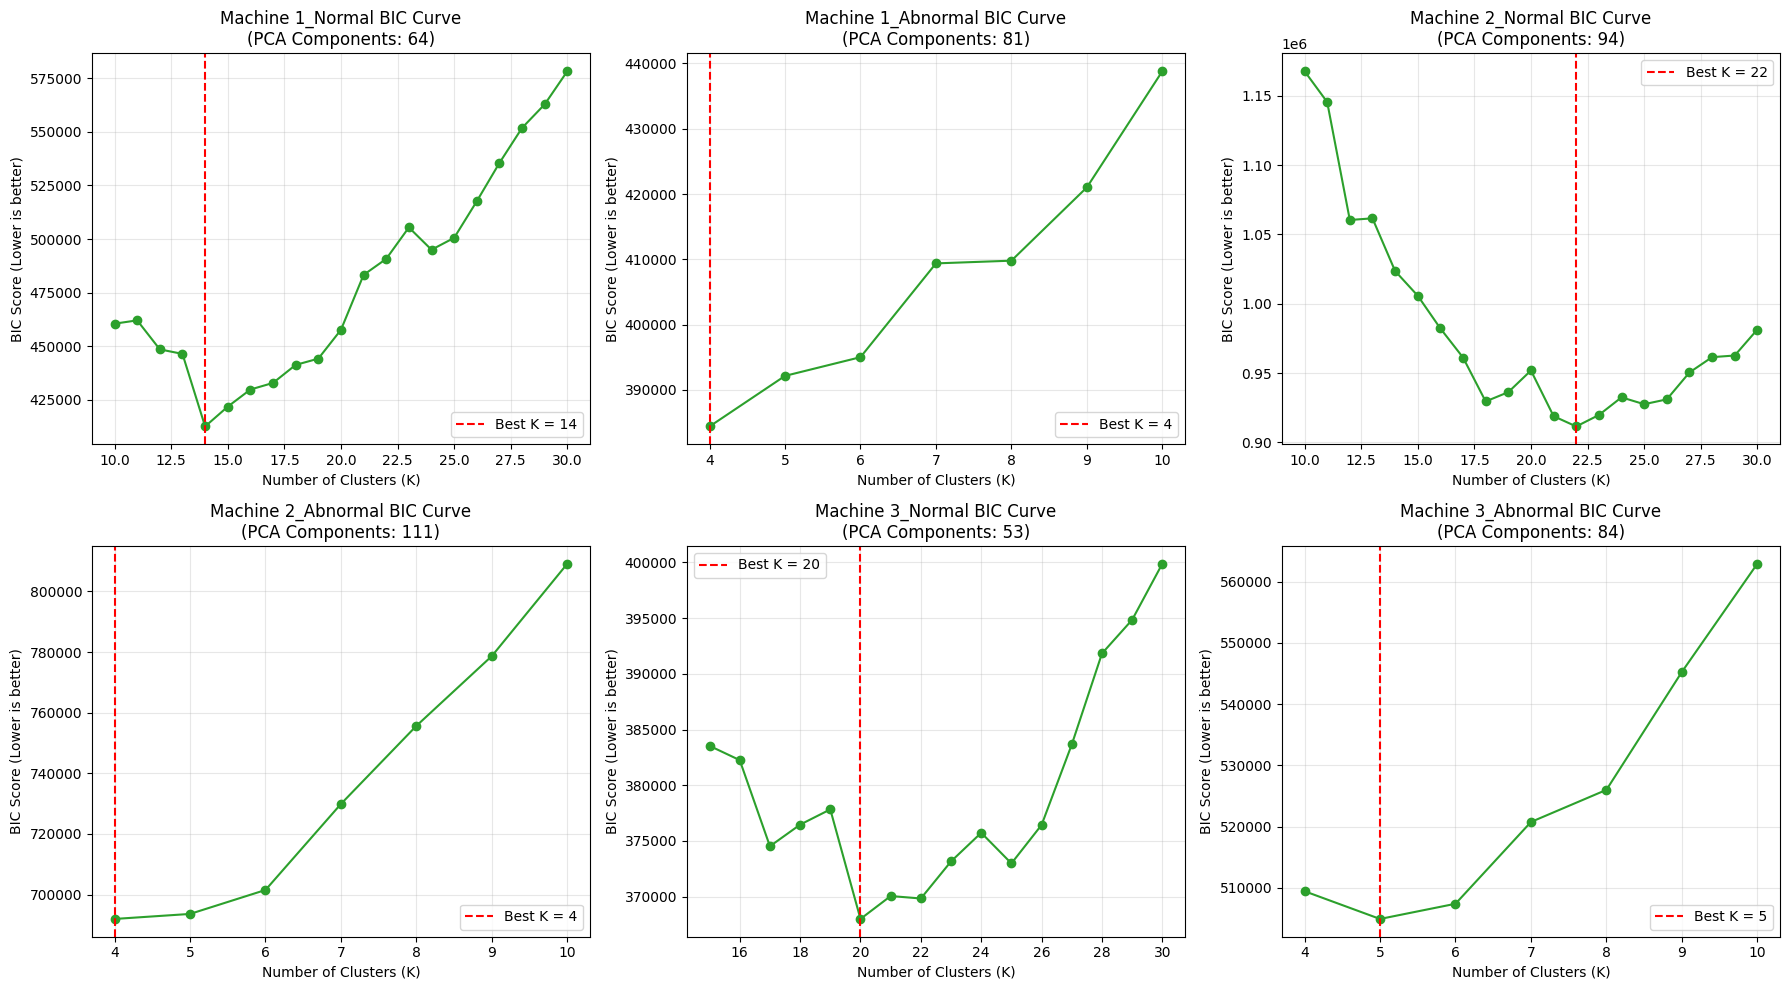


🎯 COPY-PASTE THIS NEW K_MAP INTO YOUR SPLITTING CELL:
K_MAP = {'Machine 1_Normal': 14, 'Machine 1_Abnormal': 4, 'Machine 2_Normal': 22, 'Machine 2_Abnormal': 4, 'Machine 3_Normal': 20, 'Machine 3_Abnormal': 5}


In [4]:
import numpy as np
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

print("🔍 RUNNING BIC SEARCH TO FIND OPTIMAL CLUSTERS PER CLASS...\n" + "="*50)

LABEL_MAP = {
    "Machine 1_Normal": 0, "Machine 1_Abnormal": 1,
    "Machine 2_Normal": 2, "Machine 2_Abnormal": 3,
    "Machine 3_Normal": 4, "Machine 3_Abnormal": 5
}

MIN_K_MAP = {
    "Machine 1_Normal": 10,  
    "Machine 1_Abnormal": 4,
    "Machine 2_Normal": 10, 
    "Machine 2_Abnormal": 4,
    "Machine 3_Normal": 15, 
    "Machine 3_Abnormal": 4
}

MAX_K_MAP = {
    "Machine 1_Normal": 30,  
    "Machine 1_Abnormal": 10,
    "Machine 2_Normal": 30, 
    "Machine 2_Abnormal": 10,
    "Machine 3_Normal": 30, 
    "Machine 3_Abnormal": 10
}

optimal_k_map = {}
max_k_to_search = 30 # Maximum number of sessions/clusters to test

plt.figure(figsize=(18, 10))

for i, (class_name, class_id) in enumerate(LABEL_MAP.items()):
    print(f"⚙️ Analyzing {class_name}...")
    
    # 1. Isolate class data
    class_mask = np.where(y_full == class_id)[0]
    X_class = embeddings[class_mask]
    
    if len(X_class) < 2:
        print(f"   Not enough data for {class_name}")
        continue
        
    # 2. PCA Reduction: Dynamically keep 95% of the variance
    # Setting n_components to a float between 0.0 and 1.0 tells sklearn to 
    # automatically select the number of components needed to retain that variance threshold.
    # Note: We specify svd_solver='full' to ensure exact calculations when using a float.
    pca = PCA(n_components=0.95, svd_solver='full', random_state=42)
    X_pca = pca.fit_transform(X_class)
    
    print(f"   PCA Retained 95% variance using {pca.n_components_} components (out of {X_class.shape[1]})")
    
    bics = []
    # Dynamic range to ensure we don't test more K's than we have data points
    k_range = range(MIN_K_MAP[class_name], min(MAX_K_MAP[class_name] + 1, len(X_pca)))
    print(f"   Testing Ks: {list(k_range)}")
    
    for k in k_range:
        gmm = GaussianMixture(n_components=k, covariance_type='full', random_state=42, n_init=1)
        gmm.fit(X_pca)
        bics.append(gmm.bic(X_pca))
        
    # 3. Find the K with the lowest BIC score
    best_k = k_range[np.argmin(bics)]
    optimal_k_map[class_name] = best_k
    print(f"   ✅ Optimal K found: {best_k}\n")
    
    # 4. Plotting the BIC curve
    plt.subplot(2, 3, i + 1)
    plt.plot(k_range, bics, marker='o', color='#2ca02c')
    plt.axvline(x=best_k, color='r', linestyle='--', label=f'Best K = {best_k}')
    plt.title(f"{class_name} BIC Curve\n(PCA Components: {pca.n_components_})")
    plt.xlabel("Number of Clusters (K)")
    plt.ylabel("BIC Score (Lower is better)")
    plt.grid(True, alpha=0.3)
    plt.legend()

plt.tight_layout()
plt.show()

# 5. Output the final map
print("\n" + "="*50)
print("🎯 COPY-PASTE THIS NEW K_MAP INTO YOUR SPLITTING CELL:")
print("="*50)
print("K_MAP =", optimal_k_map)

In [5]:
print("🔀 Running Per-Class GMM and Stratified Splitting...")

LABEL_MAP = {
    "Machine 1_Normal": 0, "Machine 1_Abnormal": 1,
    "Machine 2_Normal": 2, "Machine 2_Abnormal": 3,
    "Machine 3_Normal": 4, "Machine 3_Abnormal": 5
}

# Define how many clusters (sessions) you expect per class
# (You can adjust these K values based on your physical recording sessions)
K_MAP = optimal_k_map

train_indices = []
val_indices = []
test_indices = []

for class_name, class_id in LABEL_MAP.items():
    
    # 1. Isolate the embeddings specifically for this class
    class_mask = np.where(y_full == class_id)[0]
    X_class_256d = embeddings[class_mask]
    
    k = K_MAP[class_name] 
    
    # 2. Fit GMM purely on this single class
    gmm = GaussianMixture(n_components=k, covariance_type='full', random_state=42, n_init=1)
    cluster_labels = gmm.fit_predict(X_class_256d)
    
    unique_clusters = np.unique(cluster_labels)
    num_clusters = len(unique_clusters)
    
    # 3. Calculate cluster splits (60/20/20)
    num_val_clusters = max(1, int(np.round(num_clusters * 0.20)))
    num_test_clusters = max(1, int(np.round(num_clusters * 0.20)))
    
    np.random.seed(42) 
    shuffled_clusters = np.random.permutation(unique_clusters)
    
    val_clusters = shuffled_clusters[:num_val_clusters]
    test_clusters = shuffled_clusters[num_val_clusters : num_val_clusters + num_test_clusters]
    train_clusters = shuffled_clusters[num_val_clusters + num_test_clusters:]
    
    print(f"🟢 {class_name}: {num_clusters} Clusters -> Train: {len(train_clusters)}, Val: {len(val_clusters)}, Test: {len(test_clusters)}")
    
    # 4. Map the physical session clusters back to the global indices
    for i, global_idx in enumerate(class_mask):
        point_cluster = cluster_labels[i] 
        
        if point_cluster in val_clusters:
            val_indices.append(global_idx)
        elif point_cluster in test_clusters:
            test_indices.append(global_idx)
        else:
            train_indices.append(global_idx)

# Convert lists to arrays and shuffle
train_indices = np.random.permutation(np.array(train_indices))
val_indices = np.random.permutation(np.array(val_indices))
test_indices = np.random.permutation(np.array(test_indices))

# Create the final datasets
X_train, y_train = embeddings[train_indices], y_full[train_indices]
X_val, y_val = embeddings[val_indices], y_full[val_indices]
X_test, y_test = embeddings[test_indices], y_full[test_indices]

print("\n" + "="*50)
print("✅ SPLITTING COMPLETE (No Leakage!)")
print(f"   Train Set:  {len(X_train)} samples")
print(f"   Val Set:    {len(X_val)} samples")
print(f"   Test Set:   {len(X_test)} samples")
print("="*50)

🔀 Running Per-Class GMM and Stratified Splitting...
🟢 Machine 1_Normal: 14 Clusters -> Train: 8, Val: 3, Test: 3
🟢 Machine 1_Abnormal: 4 Clusters -> Train: 2, Val: 1, Test: 1
🟢 Machine 2_Normal: 22 Clusters -> Train: 14, Val: 4, Test: 4
🟢 Machine 2_Abnormal: 4 Clusters -> Train: 2, Val: 1, Test: 1
🟢 Machine 3_Normal: 20 Clusters -> Train: 12, Val: 4, Test: 4
🟢 Machine 3_Abnormal: 5 Clusters -> Train: 3, Val: 1, Test: 1

✅ SPLITTING COMPLETE (No Leakage!)
   Train Set:  34307 samples
   Val Set:    10440 samples
   Test Set:   11489 samples


In [6]:
print("💾 Saving stratified datasets to disk...")

output_dir = "prepared_data"
os.makedirs(output_dir, exist_ok=True)

train_path = os.path.join(output_dir, "train_data.npz")
val_path = os.path.join(output_dir, "val_data.npz")
test_path = os.path.join(output_dir, "test_data.npz")

np.savez_compressed(train_path, X=X_train, y=y_train)
np.savez_compressed(val_path, X=X_val, y=y_val)
np.savez_compressed(test_path, X=X_test, y=y_test)

print("✅ Data perfectly segregated and saved. You can now start supervised modeling.")

💾 Saving stratified datasets to disk...
✅ Data perfectly segregated and saved. You can now start supervised modeling.


📊 Generating Cluster and Split Visualizations...


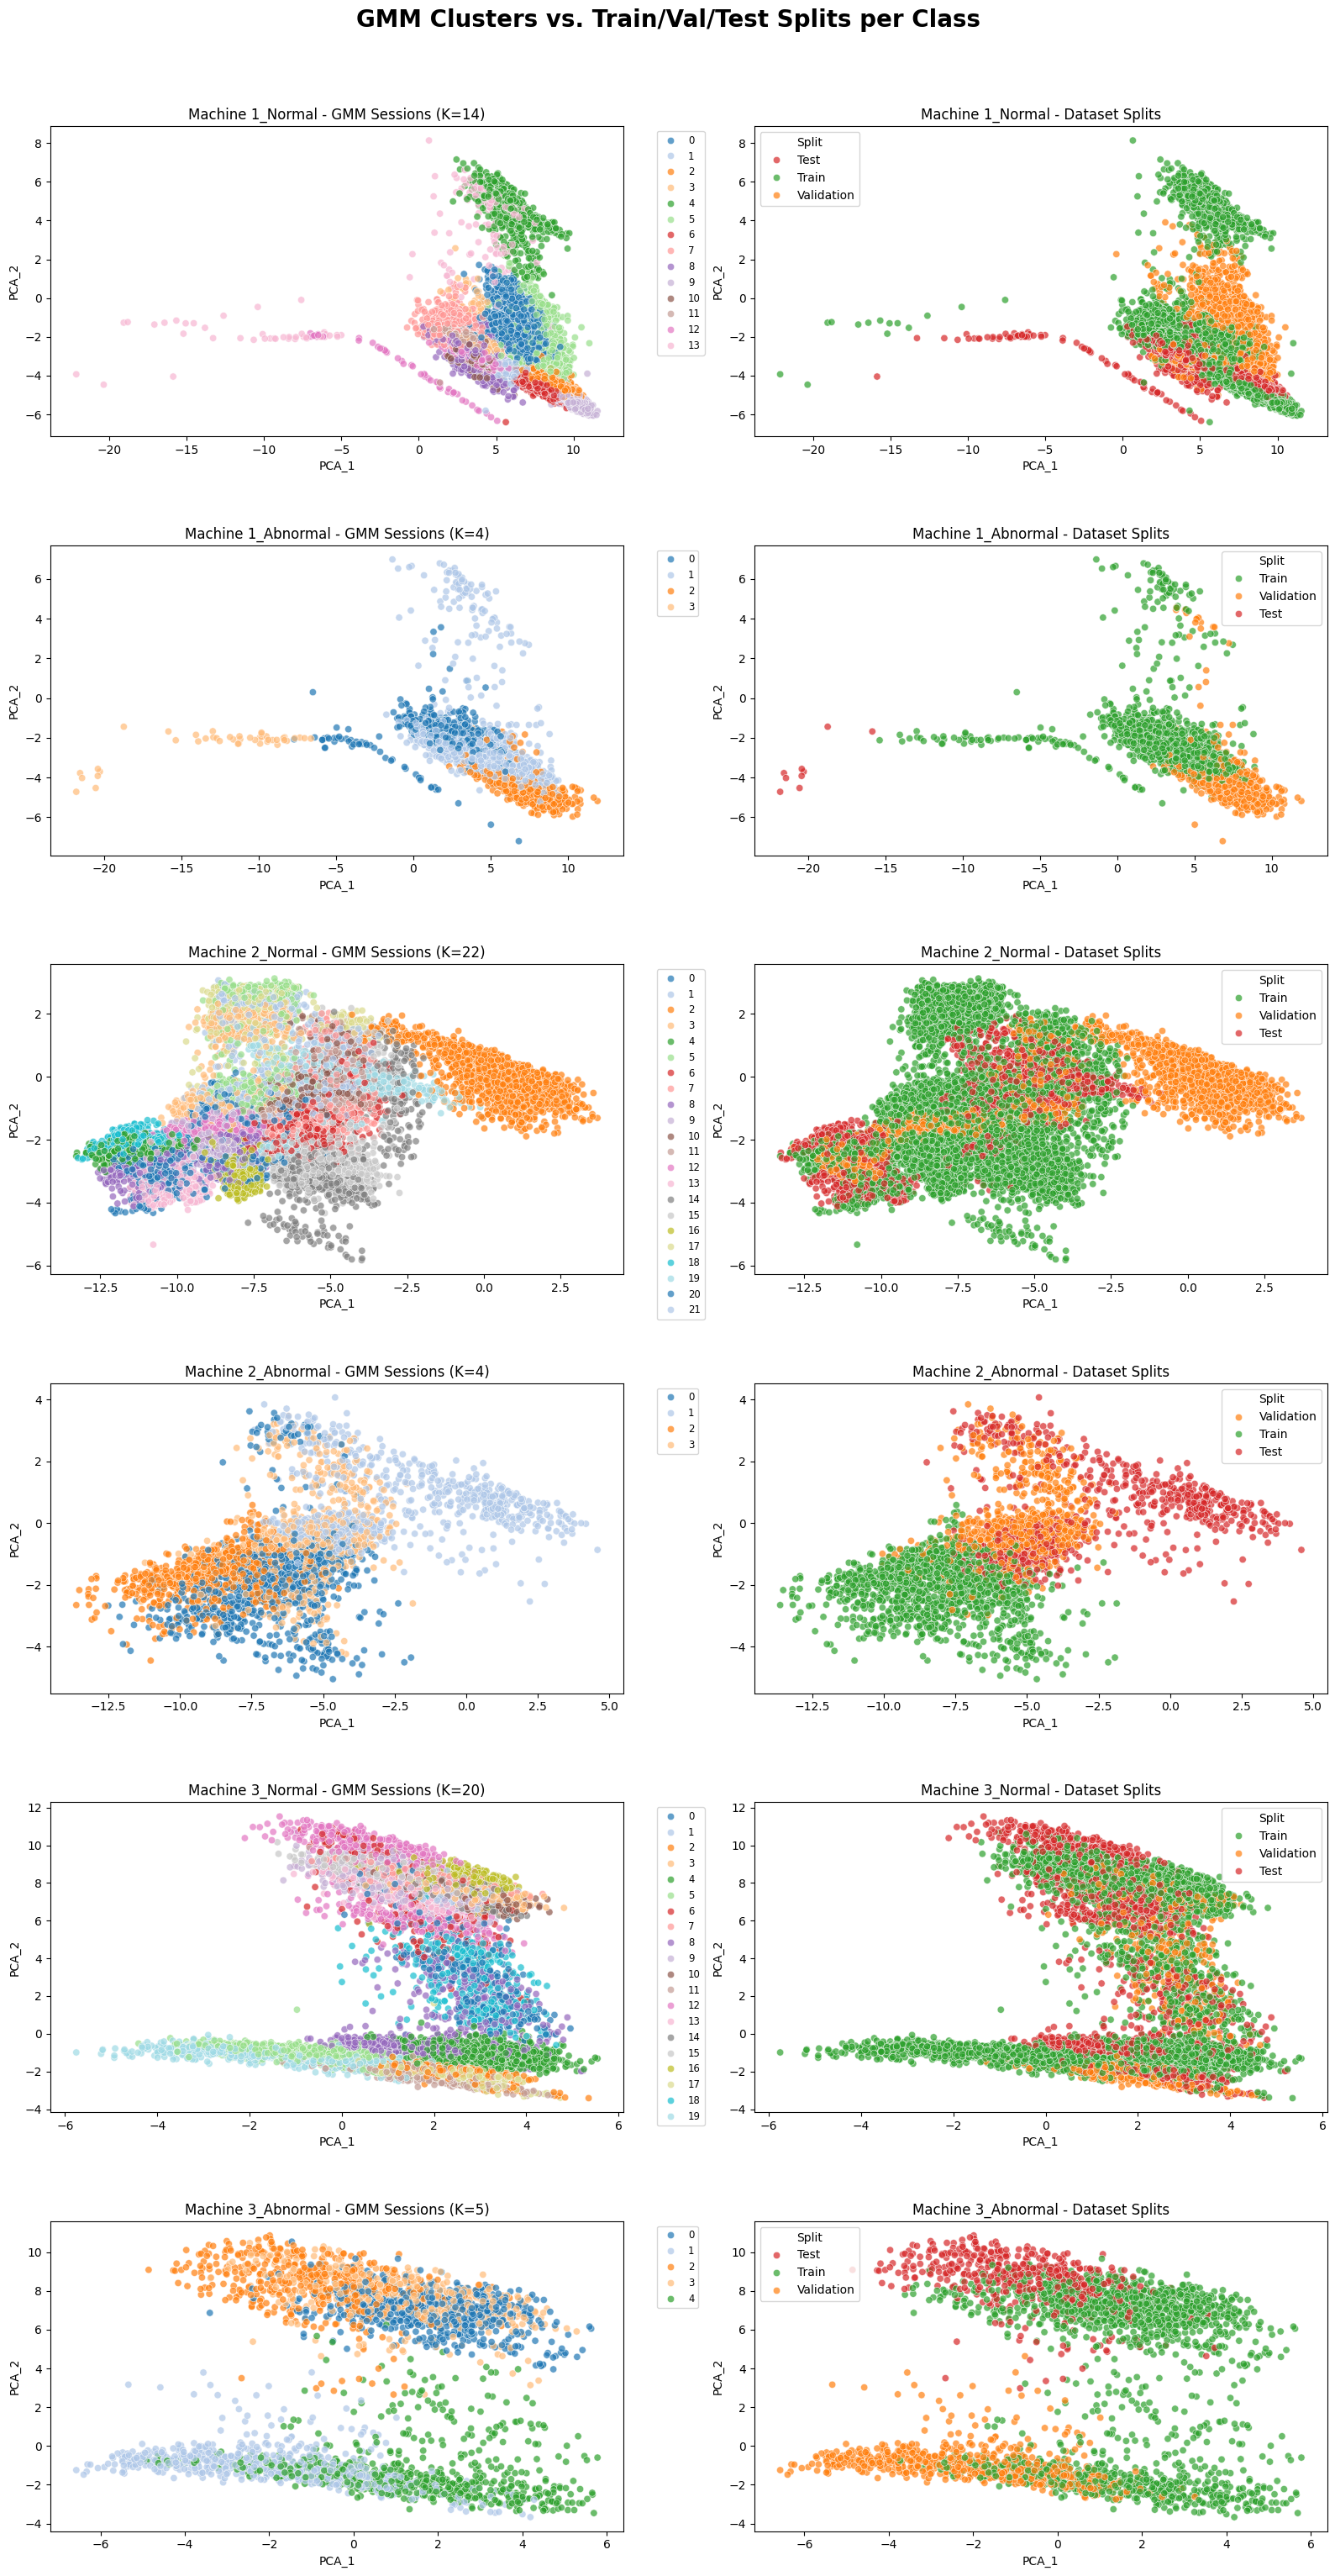

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

print("📊 Generating Cluster and Split Visualizations...")

# Create a 2D projection of the entire embedding space for fast plotting
pca_2d = PCA(n_components=2, random_state=42)
embeddings_2d = pca_2d.fit_transform(embeddings)

fig, axes = plt.subplots(len(LABEL_MAP), 2, figsize=(16, 5 * len(LABEL_MAP)))
fig.suptitle("GMM Clusters vs. Train/Val/Test Splits per Class", fontsize=20, y=1.02, fontweight='bold')

for i, (class_name, class_id) in enumerate(LABEL_MAP.items()):
    # Get original data indices for this class
    class_mask = np.where(y_full == class_id)[0]
    
    # 1. Re-fetch the GMM clusters for this class
    X_class_256d = embeddings[class_mask]
    k = optimal_k_map[class_name]
    pca_gmm = PCA(n_components=0.95, svd_solver='full', random_state=42)
    X_pca = pca_gmm.fit_transform(X_class_256d)
    gmm = GaussianMixture(n_components=k, covariance_type='full', random_state=42, n_init=1)
    cluster_labels = gmm.fit_predict(X_pca)
    
    # 2. Map splits to data points
    split_labels = []
    for global_idx in class_mask:
        if global_idx in train_indices:
            split_labels.append("Train")
        elif global_idx in val_indices:
            split_labels.append("Validation")
        else:
            split_labels.append("Test")
            
    # 3. Create DataFrame for plotting
    df_plot = pd.DataFrame({
        'PCA_1': embeddings_2d[class_mask, 0],
        'PCA_2': embeddings_2d[class_mask, 1],
        'Cluster': cluster_labels,
        'Split': split_labels
    })
    
    # Plot 1: The GMM Clusters
    sns.scatterplot(data=df_plot, x='PCA_1', y='PCA_2', hue='Cluster', palette='tab20', 
                    ax=axes[i, 0], legend='full', alpha=0.7)
    axes[i, 0].set_title(f"{class_name} - GMM Sessions (K={k})")
    axes[i, 0].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')
    
    # Plot 2: The Train/Val/Test Allocation
    sns.scatterplot(data=df_plot, x='PCA_1', y='PCA_2', hue='Split', 
                    palette={'Train': '#2ca02c', 'Validation': '#ff7f0e', 'Test': '#d62728'}, 
                    ax=axes[i, 1], alpha=0.7)
    axes[i, 1].set_title(f"{class_name} - Dataset Splits")

plt.tight_layout()
plt.show()

In [8]:
# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt
# from matplotlib.lines import Line2D
# from sklearn.decomposition import PCA
# from sklearn.manifold import TSNE
# from sklearn.mixture import GaussianMixture


# # Create a 3D projection of the entire embedding space
# # Note: If t-SNE is too slow on your full dataset, run PCA to ~50 components first:
# pca_50 = PCA(n_components=50, random_state=42).fit_transform(embeddings)
# embeddings_3d = TSNE(n_components=3, random_state=42).fit_transform(pca_50)
# print("📊 Generating 3D t-SNE Cluster and Split Visualizations...")
# tsne_3d = TSNE(n_components=3, perplexity=30, random_state=42)
# embeddings_3d = tsne_3d.fit_transform(embeddings)

# # Set up the figure (cannot use standard subplots easily for 3D grids, so we add them iteratively)
# fig = plt.figure(figsize=(16, 7 * len(LABEL_MAP)))
# fig.suptitle("3D t-SNE: GMM Clusters vs. Train/Val/Test Splits per Class", fontsize=20, y=0.98, fontweight='bold')

# # Color mapping for splits
# split_colors = {'Train': '#2ca02c', 'Validation': '#ff7f0e', 'Test': '#d62728'}

# for i, (class_name, class_id) in enumerate(LABEL_MAP.items()):
#     # Get original data indices for this class
#     class_mask = np.where(y_full == class_id)[0]
    
#     # 1. Re-fetch the GMM clusters for this class
#     X_class_256d = embeddings[class_mask]
#     k = optimal_k_map[class_name]
#     pca_gmm = PCA(n_components=0.95, svd_solver='full', random_state=42)
#     X_pca = pca_gmm.fit_transform(X_class_256d)
#     gmm = GaussianMixture(n_components=k, covariance_type='full', random_state=42, n_init=1)
#     cluster_labels = gmm.fit_predict(X_pca)
    
#     # 2. Map splits to data points and assign colors
#     split_labels = []
#     split_c = []
#     for global_idx in class_mask:
#         if global_idx in train_indices:
#             split_labels.append("Train")
#             split_c.append(split_colors['Train'])
#         elif global_idx in val_indices:
#             split_labels.append("Validation")
#             split_c.append(split_colors['Validation'])
#         else:
#             split_labels.append("Test")
#             split_c.append(split_colors['Test'])
            
#     # 3. Create DataFrame for plotting
#     df_plot = pd.DataFrame({
#         'tSNE_1': embeddings_3d[class_mask, 0],
#         'tSNE_2': embeddings_3d[class_mask, 1],
#         'tSNE_3': embeddings_3d[class_mask, 2],
#         'Cluster': cluster_labels,
#         'Split': split_labels,
#         'SplitColor': split_c
#     })
    
#     # --- Plot 1: The GMM Clusters (Left Column) ---
#     ax1 = fig.add_subplot(len(LABEL_MAP), 2, 2 * i + 1, projection='3d')
#     scatter1 = ax1.scatter(df_plot['tSNE_1'], df_plot['tSNE_2'], df_plot['tSNE_3'], 
#                            c=df_plot['Cluster'], cmap='tab20', alpha=0.7, s=15)
#     ax1.set_title(f"{class_name}\nGMM Sessions (K={k})", fontweight='bold')
#     ax1.set_xlabel('t-SNE 1')
#     ax1.set_ylabel('t-SNE 2')
#     ax1.set_zlabel('t-SNE 3')
    
#     # --- Plot 2: The Train/Val/Test Allocation (Right Column) ---
#     ax2 = fig.add_subplot(len(LABEL_MAP), 2, 2 * i + 2, projection='3d')
#     ax2.scatter(df_plot['tSNE_1'], df_plot['tSNE_2'], df_plot['tSNE_3'], 
#                 c=df_plot['SplitColor'], alpha=0.7, s=15)
#     ax2.set_title(f"{class_name}\nDataset Splits", fontweight='bold')
#     ax2.set_xlabel('t-SNE 1')
#     ax2.set_ylabel('t-SNE 2')
#     ax2.set_zlabel('t-SNE 3')
    
#     # Create custom legend for the Splits
#     legend_elements = [
#         Line2D([0], [0], marker='o', color='w', label='Train', markerfacecolor=split_colors['Train'], markersize=8),
#         Line2D([0], [0], marker='o', color='w', label='Validation', markerfacecolor=split_colors['Validation'], markersize=8),
#         Line2D([0], [0], marker='o', color='w', label='Test', markerfacecolor=split_colors['Test'], markersize=8)
#     ]
#     ax2.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(1.05, 1))

# plt.tight_layout()
# plt.show()

In [9]:
# import pandas as pd
# import numpy as np
# import plotly.express as px
# import plotly.graph_objects as go
# from sklearn.decomposition import PCA
# from sklearn.manifold import TSNE
# from sklearn.mixture import GaussianMixture

# print("📊 Generating Interactive 3D t-SNE Visualizations...")

# # ─── 1. DIMENSIONALITY REDUCTION (t-SNE) ────────────────────────────────────
# # To speed up t-SNE, we first reduce the 256D embeddings to 50D using PCA
# pca_50 = PCA(n_components=50, random_state=42)
# embeddings_pca50 = pca_50.fit_transform(embeddings)

# # Now run t-SNE to get the 3D coordinates
# tsne_3d = TSNE(n_components=3, perplexity=30, random_state=42)
# embeddings_3d = tsne_3d.fit_transform(embeddings_pca50)

# # ─── 2. PLOT GENERATION ─────────────────────────────────────────────────────

# # We will create a list to store the figures so they display nicely
# figures = []

# for class_name, class_id in LABEL_MAP.items():
#     print(f"⚙️ Processing {class_name}...")
    
#     # Isolate original data indices for this class
#     class_mask = np.where(y_full == class_id)[0]
    
#     # Re-fetch the GMM clusters for this class
#     X_class_256d = embeddings[class_mask]
#     k = optimal_k_map[class_name]
    
#     # Run the GMM again to get cluster assignments
#     pca_gmm = PCA(n_components=0.95, svd_solver='full', random_state=42)
#     X_pca = pca_gmm.fit_transform(X_class_256d)
#     gmm = GaussianMixture(n_components=k, covariance_type='full', random_state=42, n_init=1)
#     cluster_labels = gmm.fit_predict(X_pca)
    
#     # Map splits to data points
#     split_labels = []
#     for global_idx in class_mask:
#         if global_idx in train_indices:
#             split_labels.append("Train")
#         elif global_idx in val_indices:
#             split_labels.append("Validation")
#         else:
#             split_labels.append("Test")
            
#     # Create a DataFrame for Plotly
#     df_plot = pd.DataFrame({
#         'tSNE_1': embeddings_3d[class_mask, 0],
#         'tSNE_2': embeddings_3d[class_mask, 1],
#         'tSNE_3': embeddings_3d[class_mask, 2],
#         'Cluster': [f"Cluster {c}" for c in cluster_labels], # Make them strings for discrete colors
#         'Split': split_labels
#     })
    
#     # --- Plotly Figure: Splits ---
#     # We plot the Splits because that's usually the most important thing to check for leakage
#     color_map = {'Train': '#2ca02c', 'Validation': '#ff7f0e', 'Test': '#d62728'}
    
#     fig = px.scatter_3d(
#         df_plot, 
#         x='tSNE_1', y='tSNE_2', z='tSNE_3',
#         color='Split',
#         color_discrete_map=color_map,
#         hover_data=['Cluster'], # Shows the GMM cluster when you hover!
#         title=f"<b>{class_name}</b><br>Dataset Splits in 3D Space (Hover for GMM Cluster)",
#         opacity=0.7
#     )
    
#     # Make the markers slightly smaller for better visibility
#     fig.update_traces(marker=dict(size=4))
    
#     # Adjust layout
#     fig.update_layout(
#         margin=dict(l=0, r=0, b=0, t=50),
#         legend=dict(yanchor="top", y=0.99, xanchor="left", x=0.01)
#     )
    
#     figures.append(fig)

# # ─── 3. DISPLAY THE PLOTS ───────────────────────────────────────────────────
# print("\n✅ Done! Rendering interactive plots...")
# for fig in figures:
#     fig.show()